In [77]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

importando dataset iris do conjunto de datasets salvos no SKlearn

In [78]:
iris = pd.read_csv("iris.csv.xls")

feature_cols = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
X = iris[feature_cols] # Features
y = iris.Name # Target variable

testando

In [79]:
print(X)

     SepalLength  SepalWidth  PetalLength  PetalWidth
0            5.1         3.5          1.4         0.2
1            4.9         3.0          1.4         0.2
2            4.7         3.2          1.3         0.2
3            4.6         3.1          1.5         0.2
4            5.0         3.6          1.4         0.2
..           ...         ...          ...         ...
145          6.7         3.0          5.2         2.3
146          6.3         2.5          5.0         1.9
147          6.5         3.0          5.2         2.0
148          6.2         3.4          5.4         2.3
149          5.9         3.0          5.1         1.8

[150 rows x 4 columns]


adequando o data set para o meu traballho de não suupervisionado(vou retirar os rotulos/labels)

In [80]:
iris_dados=X.to_numpy()
print(iris_dados)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

outra alternativa usar a estrutura que a biblioteca do sklearn me oferece atraves dos datasets(já certo)

In [81]:
iris_df=datasets.load_iris()
print(iris_df)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

recebendo apenas as colunas 0 e 2 do dataset

In [82]:
eixoX = iris_df.data[:,0] #sepal Length
eixoY = iris_df.data[:,2] #Petal Length

Plottar a distribuição dos meus resultados

<function matplotlib.pyplot.show(close=None, block=None)>

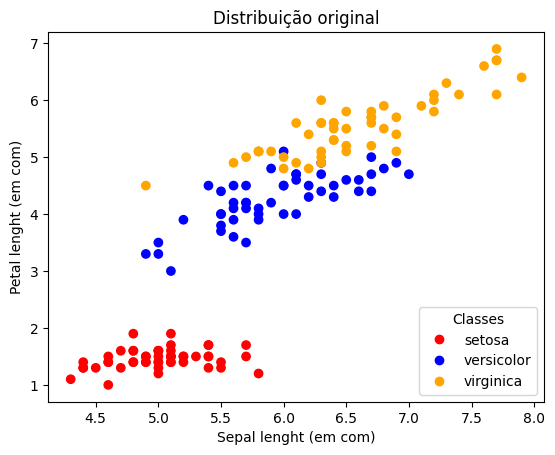

In [ ]:
cores = ListedColormap(["red","blue", "orange"])
fig,ax=plt.subplots()
scatter = plt.scatter(eixoX,eixoY,c=iris_df.target,cmap=cores)
plt.xlabel("Sepal lenght (em cm)")
plt.ylabel("Petal lenght (em cm)")
plt.title("Distribuição original")
ax.legend(scatter.legend_elements()[0],iris_df.target_names,loc="lower right",title="Classes")
plt.show

iniciando os trabalhos com Kmeans

In [84]:
modeloKmeans=KMeans(n_clusters=3)
modeloKmeans=modeloKmeans.fit(iris_dados)
#modeloKmeans=modeloKmeans.fit(iris_df)

Predizendo todos os elemento e checando a distribuição da matriz de confusão

In [85]:
todasAspredicoes=modeloKmeans.predict(iris_dados)
cm = confusion_matrix(iris_df.target, todasAspredicoes)
print(cm)
print(todasAspredicoes)

[[ 0 50  0]
 [ 3  0 47]
 [36  0 14]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


Predizer um elemento,ele vai informar uma classe que ele acha que o meu elemento pertence.

In [ ]:
umaPredicao = modeloKmeans.predict([[7.2,3.2,6.0,1.8]])
print(umaPredicao)
#setosa = classe 1
#versicolor= classe 0
#virginica = classe 2

[0]


plottar em scatterplot a distribuição das minhas classes

<function matplotlib.pyplot.show(close=None, block=None)>

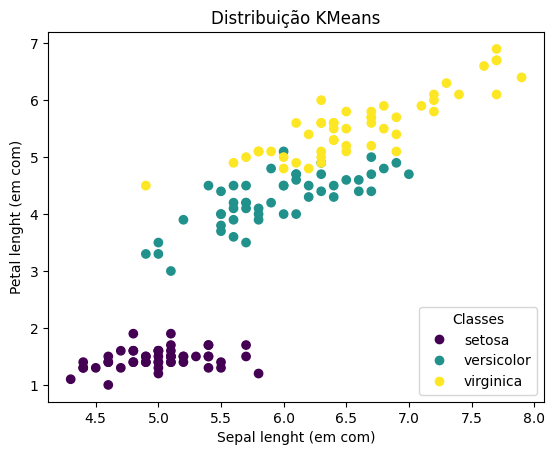

In [ ]:
#cores = ListedColormap(["red","blue", "orange"])
fig,ax=plt.subplots()
scatter = plt.scatter(eixoX,eixoY,c=iris_df.target)
plt.xlabel("Sepal lenght (em cm)")
plt.ylabel("Petal lenght (em cm)")
plt.title("Distribuição KMeans")
ax.legend(scatter.legend_elements()[0],iris_df.target_names,loc="lower right",title="Classes")
plt.show